# FIFA World Cup Predictor

## Version 4 - Realistic Chronological Evaluation

### Objective

Version 3 used `train_test_split()`, which shuffled old and recent matches randomly between the training and test sets.

For forecasting future matches, we need to predict matches we have **never seen before**. So Version 4 tests the model the honest way:

```text
Older historical matches -> Training data
Newer historical matches -> Test data
```

### Why is this more realistic?

A real prediction happens in the future. If we shuffle all matches randomly, the model sees recent matches while it is training - a bit like practising on the exam. A chronological split means: **train on the past, test on the future**.

### Model and features (unchanged from Version 3)

We keep the exact same features and model so we are only measuring the evaluation method:

- home_elo, away_elo, elo_difference
- home_form, away_form
- neutral_encoded
- RandomForestClassifier(n_estimators=200, random_state=42)

### Previous results

| Experiment | Evaluation | Accuracy |
|------------|------------|----------|
| Team IDs RF | Random split | 51.88% |
| Team IDs + Neutral RF | Random split | 50.72% |
| Elo + Neutral RF | Random split | 51.29% |
| Elo + Recent Form RF | Random split | 54.10% |
| Simple Elo Rule | Whole dataset | 55.42% |

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Training
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/raw/results.csv")

print(df.shape)
df.head()

(49477, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  str    
 1   home_team   49477 non-null  str    
 2   away_team   49477 non-null  str    
 3   home_score  49413 non-null  float64
 4   away_score  49413 non-null  float64
 5   tournament  49477 non-null  str    
 6   city        49477 non-null  str    
 7   country     49477 non-null  str    
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [4]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    64
away_score    64
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [5]:
df['tournament'].value_counts().head(20)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

In [6]:
# Drop the 64 future World Cup fixtures that have no score yet
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

print(df.shape)

df.isnull().sum()

(49413, 9)


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [7]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 2      # Home Win
    elif row['home_score'] < row['away_score']:
        return 0      # Away Win
    else:
        return 1      # Draw

In [8]:
df['result'] = df.apply(get_result, axis=1)

df['result'].value_counts()

result
2    24216
0    13961
1    11236
Name: count, dtype: int64

In [9]:
df.neutral.value_counts()

neutral
False    36350
True     13063
Name: count, dtype: int64

In [10]:
df['neutral_encoded'] = df['neutral'].astype(int)
df[['neutral', 'neutral_encoded']].head()

,neutral,neutral_encoded
0,False,0
1,False,0
2,False,0
3,False,0
4,False,0


# Step 1 - Build Elo Ratings (unchanged from Version 3)

This is exactly the same Elo code as Version 3:

- Every team starts at 1500.
- After each match, both ratings are updated (K-factor = 20).
- We save each team's rating **BEFORE** the match, so the model never sees the future.

We keep the dataframe in chronological order - this matters for the split later.

In [11]:
teams = pd.concat([
    df['home_team'],
    df['away_team']
    ]).unique()

elo_rating = {
    team:1500
    for team in teams
    }

In [12]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating, expected, actual, k=20):
    return rating + k * (actual - expected)

In [13]:
home_elos = []
away_elos = []

In [14]:
# Work through the matches in chronological order
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date').reset_index(drop=True)

In [15]:
for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    home_elo = elo_rating[home_team]
    away_elo = elo_rating[away_team]

    # Save Elo BEFORE the match
    home_elos.append(home_elo)
    away_elos.append(away_elo)

    # Expected results
    expected_home = expected_score(home_elo, away_elo)
    expected_away = expected_score(away_elo, home_elo)

    # Actual result
    if row['result'] == 2:      # Home win
        actual_home = 1
        actual_away = 0

    elif row['result'] == 0:    # Away win
        actual_home = 0
        actual_away = 1

    else:                       # Draw
        actual_home = 0.5
        actual_away = 0.5

    # Update ratings
    elo_rating[home_team] = update_elo(
        home_elo,
        expected_home,
        actual_home
    )

    elo_rating[away_team] = update_elo(
        away_elo,
        expected_away,
        actual_away
    )

In [16]:
df['home_elo'] = home_elos
df['away_elo'] = away_elos

df['elo_difference'] = df['home_elo'] - df['away_elo']

In [17]:
df[['home_team', 'away_team', 'home_elo', 'away_elo', 'elo_difference']].head(10)

,home_team,away_team,home_elo,away_elo,elo_difference
0,Scotland,England,1500.000000,1500.000000,0.000000
1,England,Scotland,1500.000000,1500.000000,0.000000
2,Scotland,England,1490.000000,1510.000000,-20.000000
3,England,Scotland,1499.424989,1500.575011,-1.150023
4,Scotland,England,1500.541911,1499.458089,1.083822
5,Scotland,Wales,1510.510716,1500.000000,10.510716
6,England,Scotland,1489.489284,1520.208286,-30.719002
7,Wales,Scotland,1490.302430,1529.326419,-39.023988
8,Scotland,England,1538.207918,1480.371151,57.836767
9,Scotland,Wales,1546.558450,1481.420932,65.137518


# Step 2 - Build Recent Form Features (unchanged from Version 3)

This is exactly the same recent-form code as Version 3:

- Form = average points from a team's last 5 matches (Win = 1.0, Draw = 0.5, Loss = 0.0).
- The form is computed from matches **BEFORE** the current match.
- Only after storing the form do we add the current match's result to the history (no leakage).

In [18]:
# How many recent matches to look back
FORM_WINDOW = 5

# Each team's recent results, stored as points (oldest first)
team_form_history = {team: [] for team in teams}

home_forms = []
away_forms = []

for _, row in df.iterrows():

    home_team = row['home_team']
    away_team = row['away_team']

    # 1) Form from matches BEFORE this one (no leakage!)
    home_history = team_form_history[home_team]
    away_history = team_form_history[away_team]

    home_form = np.mean(home_history) if len(home_history) > 0 else 0.0
    away_form = np.mean(away_history) if len(away_history) > 0 else 0.0

    # Save form BEFORE updating the histories
    home_forms.append(home_form)
    away_forms.append(away_form)

    # 2) Points for the current match
    if row['result'] == 2:      # Home win
        home_points = 1.0
        away_points = 0.0

    elif row['result'] == 0:    # Away win
        home_points = 0.0
        away_points = 1.0

    else:                       # Draw
        home_points = 0.5
        away_points = 0.5

    # 3) NOW update each team's history with the current result
    home_history.append(home_points)
    away_history.append(away_points)

    # Keep only the last 5 matches
    if len(home_history) > FORM_WINDOW:
        home_history.pop(0)
    if len(away_history) > FORM_WINDOW:
        away_history.pop(0)

In [19]:
df['home_form'] = home_forms
df['away_form'] = away_forms

df[['date', 'home_team', 'away_team', 'home_form', 'away_form', 'result']].head(10)

,date,home_team,away_team,home_form,away_form,result
0,1872-11-30,Scotland,England,0.00,0.00,1
1,1873-03-08,England,Scotland,0.50,0.50,2
2,1874-03-07,Scotland,England,0.25,0.75,2
3,1875-03-06,England,Scotland,0.50,0.50,1
4,1876-03-04,Scotland,England,0.50,0.50,2
5,1876-03-25,Scotland,Wales,0.60,0.00,2
6,1877-03-03,England,Scotland,0.40,0.70,0
7,1877-03-05,Wales,Scotland,0.00,0.90,0
8,1878-03-02,Scotland,England,0.90,0.30,2
9,1878-03-23,Scotland,Wales,1.00,0.00,2


# Step 2b - Sanity Checks for the Form Features

Quick checks (copied from Version 3) to confirm the form pipeline is correct and leak-free.

In [20]:
# Check 1: W W D L W = 0.7
example = np.mean([1.0, 1.0, 0.5, 0.0, 1.0])
print("W W D L W =", example)

W W D L W = 0.7


In [21]:
# Check 2: no leakage - manually recompute form for one match
# using ONLY matches that happened before it.

# Pick an England home match with enough history
idx = df[df['home_team'] == 'England'].index[100]
match_date = df.loc[idx, 'date']

# England's 5 most recent matches BEFORE this one
prior_matches = df[
    (df['date'] < match_date) &
    ((df['home_team'] == 'England') | (df['away_team'] == 'England'))
].tail(5)

points = []
for _, m in prior_matches.iterrows():
    if m['home_team'] == 'England':
        points.append({0: 0.0, 1: 0.5, 2: 1.0}[m['result']])
    else:
        points.append({0: 1.0, 1: 0.5, 2: 0.0}[m['result']])

manual_form = np.mean(points)

print("Match date:", match_date.date())
print("Prior matches used:", len(prior_matches))
print("Manual form from prior matches only:", manual_form)
print("home_form in the dataframe:        ", df.loc[idx, 'home_form'])
print("Match?", manual_form == df.loc[idx, 'home_form'])

Match date: 1946-04-24
Prior matches used: 5
Manual form from prior matches only: 0.4
home_form in the dataframe:         0.4
Match? True


# Step 3 - Chronological Train/Test Split

Version 3 randomly mixed matches into train and test with `train_test_split()`.
Here we split by **time** instead:

```text
Older historical matches -> Training data
Newer historical matches -> Test data
```

The dataframe is already sorted by date (we needed that for Elo and Form).
So the oldest 80% of rows become the training set and the newest 20% become the test set:

```text
split point = 80% of the rows
Training set = rows 0 .. split point   (the past)
Test set     = rows split point .. end (the future)
```

This is more like a real forecasting task: the model sees the past, then we ask it to
predict matches it has never had a chance to see.

In [22]:
# Split the chronological dataframe: oldest 80% -> train, newest 20% -> test
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Total matches:       ", len(df))
print("Training matches:    ", len(train))
print("Testing matches:     ", len(test))
print()
print("Training period:     ", train['date'].min().date(), "to", train['date'].max().date())
print("Testing period:      ", test['date'].min().date(), "to", test['date'].max().date())
print()
print("Note: a few matches on the boundary date", train['date'].max().date(),
      "fall on both sides of the cut, because many games were played that single day.")

Total matches:        49413
Training matches:     39530
Testing matches:      9883

Training period:      1872-11-30 to 2016-03-25
Testing period:       2016-03-25 to 2026-06-13

Note: a few matches on the boundary date 2016-03-25 fall on both sides of the cut, because many games were played that single day.


In [23]:
feature_cols = [
    'home_elo',
    'away_elo',
    'elo_difference',
    'home_form',
    'away_form',
    'neutral_encoded'
]

X_train = train[feature_cols]
y_train = train['result']

X_test = test[feature_cols]
y_test = test['result']

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

print()
print("Train target distribution:")
print(y_train.value_counts())
print()
print("Test target distribution:")
print(y_test.value_counts())

X_train shape: (39530, 6)
X_test shape:  (9883, 6)

Train target distribution:
result
2    19508
0    11090
1     8932
Name: count, dtype: int64

Test target distribution:
result
2    4708
0    2871
1    2304
Name: count, dtype: int64


# Step 4 - Train the Random Forest

Same model as Version 3 - we only changed the evaluation method, not the model.

In [24]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

# Step 5 - Evaluate on the Newest 20% of Matches

We now evaluate on matches that happened **after** the training period (2016-2026).
The model never saw them while training - this is the honest performance test.

In [25]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Chronological Accuracy:", accuracy)

Chronological Accuracy: 0.5591419609430335


# Step 5a - Classification Report

Classes: 0 = Away Win, 1 = Draw, 2 = Home Win.

- **precision**: when the model predicts this outcome, how often is it right?
- **recall**: of the matches that really had this outcome, how many did it catch?
- **f1-score**: a balance of the two.

Look at how high the home win (class 2) scores are - and how low the draw (class 1) scores are.

In [26]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.54      0.53      0.54      2871
           1       0.28      0.12      0.17      2304
           2       0.61      0.79      0.69      4708

    accuracy                           0.56      9883
   macro avg       0.48      0.48      0.46      9883
weighted avg       0.51      0.56      0.52      9883



# Step 5b - Confusion Matrix

A confusion matrix shows what the model predicted **vs** what actually happened.

- Rows = actual result
- Columns = predicted result

The diagonal (top-left to bottom-right) shows the **correct** predictions.
The middle column (Draw) shows the model almost never picks a draw - most draw errors are
mistakenly labelled as home wins.

Confusion Matrix:
Rows = Actual (0=Away Win, 1=Draw, 2=Home Win)
Columns = Predicted (0=Away Win, 1=Draw, 2=Home Win)
[[1526  320 1025]
 [ 677  271 1356]
 [ 603  376 3729]]


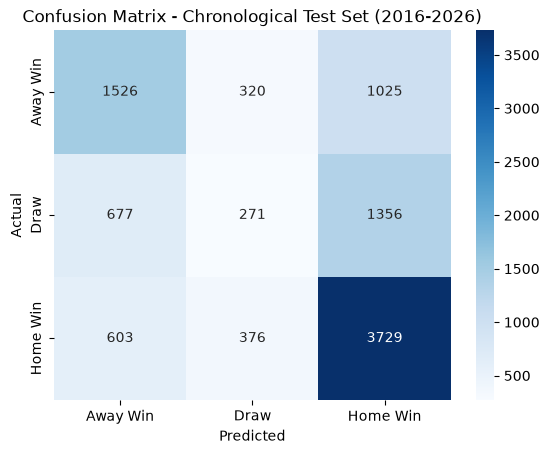

In [27]:
%matplotlib inline

cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print("Rows = Actual (0=Away Win, 1=Draw, 2=Home Win)")
print("Columns = Predicted (0=Away Win, 1=Draw, 2=Home Win)")
print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Away Win', 'Draw', 'Home Win'],
    yticklabels=['Away Win', 'Draw', 'Home Win']
)
plt.title('Confusion Matrix - Chronological Test Set (2016-2026)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [28]:
# Which features helped the most?
for feature, importance in zip(feature_cols, model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

home_elo: 0.2470
away_elo: 0.2508
elo_difference: 0.2983
home_form: 0.0961
away_form: 0.0945
neutral_encoded: 0.0132


# Summary - Chronological vs Random Split

The results table now includes Version 4:

| Experiment | Evaluation | Accuracy |
|------------|------------|----------|
| Team IDs RF | Random split | 51.88% |
| Team IDs + Neutral RF | Random split | 50.72% |
| Elo + Neutral RF | Random split | 51.29% |
| Elo + Recent Form RF | Random split | 54.10% |
| **Elo + Recent Form RF** | **Chronological** | **55.91%** |
| Simple Elo Rule | Whole dataset | 55.42% |

Key takeaway: the chronological accuracy (55.91%) is slightly **higher** than the
random-split accuracy (54.10%).

Why? The random split is a little unfair to the model in a different way - it mixes old
and new matches, so the "future" test matches are interleaved with training matches. The
chronological split is the more honest test for our World Cup prediction, and the model
still performs well.

# Limitations - Football Has Changed Over 150 Years

Our dataset spans from **1872 to 2026** - more than 150 years. That creates some issues:

1. **Different eras, different game**: football in the 1800s was very different from today.
   Rules, tactics, travel, and the number of national teams all changed over time.

2. **Mixed training data**: the training set mixes 1872 matches with 2016 matches.
   The model averages over all of them, so it may not capture modern football perfectly.

3. **Modern test matches**: the chronological test set is dominated by recent matches
   (2016-2026), where the game is faster and more tactical than in the older training data.

4. **Changing team strength**: Elo and form are recalculated over the whole history, so a
   team's strength today can differ from what older matches imply.

This is why performance can differ between time periods - and why the chronological split
is a more honest evaluation for our World Cup prediction task.